In [136]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from src.data.data import get_ds

In [137]:
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}

train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)


# class_to_index={"epilepsy":0, "walking":1, "running":2,"sawing":3}

# train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/epilepsy/Epilepsy_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/epilepsy/Epilepsy_TEST.ts", class_to_index)
# len(train_ds)

40

In [138]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, num_layers, dropout):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, dropout=self.dropout, batch_first=True)
        self.fc_mu = nn.Linear(self.hidden_size * self.num_layers, self.latent_size)
        self.fc_var = nn.Linear(self.hidden_size * self.num_layers, self.latent_size)


    def forward(self, x):
        """
        x: (batch_size, seq_len, input_size=1)
        """
        output, (hidden, cell) = self.lstm(x)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        mean = self.fc_mu(hidden)
        log_var = self.fc_var(hidden)
        # mean: (1, batch_size, latent_size) assuming num_layers=1, not sure how to do for num_layers>1 yet
        # log_var: (1, batch_size, latent_size)

        # Reparameterization
        std = torch.exp(0.5 * log_var)

        noise = torch.randn_like(mean)
        z = noise*std + mean
        # z: (1, batch_size, latent_size)
        return z, mean, log_var, hidden, cell
    
class Decoder(nn.Module):
    def __init__(self, latent_size, output_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.latent_size = latent_size
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.init_hidden_decoder = nn.Linear(in_features=self.latent_size, out_features=self.hidden_size)
        self.lstm = nn.LSTM(self.output_size, self.hidden_size, self.num_layers, dropout=self.dropout)
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, z, x):
        """
        z: (1, batch_size, latent_size)
        hidden: (num_layers, batch_size, hidden_size)
        cell: (num_layers, batch_size, hidden_size)
        """
        x = x.transpose(0, 1).unsqueeze(2)
        hidden_decoder = self.init_hidden_decoder(z)
        # hidden_decoder: (1, batch_size, hidden_size)
        hidden_cell_decoder = (hidden_decoder, hidden_decoder)

        output, (hidden, cell) = self.lstm(x, hidden_cell_decoder)
        prediction = self.fc(output)
        
        return prediction, hidden, cell

In [139]:
class Autoencoder(nn.Module):
    def __init__(self, seq_len, input_size, hidden_size, latent_size, num_layers, dropout, tf_ratio=1.0):
        super().__init__()
        
        self.seq_len = seq_len
        self.tf_ratio = tf_ratio

        self.encoder = Encoder(input_size, hidden_size, latent_size, num_layers, dropout)
        self.decoder = Decoder(latent_size, input_size, hidden_size, num_layers, dropout)

    def forward(self, x):
        z, mean, log_var, hidden, cell = self.encoder(x)
        # z: (1, batch_size, latent_size)
        # mean: (1, batch_size, latent_size)
        # log_var: (1, batch_size, latent_size)
        # hidden_size: (1, batch_size, hidden_size)
        # cell: (1, batch_size, hidden_size)

        outputs = torch.zeros_like(x)

        input = x[:, 0]
        for t in range(1, self.seq_len):
            output, hidden, cell = self.decoder(z, input)
            outputs[:, t, :] = output

            teacher_force = random.random() < self.tf_ratio
            input = x[:, t] if teacher_force else output.squeeze(0)

        return outputs, mean, log_var



In [140]:
# autoencoder = Autoencoder(100, 1, 50, 10, 1, 0, 0.5)
# data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), True)
# for data_matrix, labels in data_load:
#     inp = data_matrix[:, :, 0].unsqueeze(2).float()
#     output = autoencoder(inp)
#     print(output.size())

In [141]:
autoencoder = Autoencoder(100, 1, 50, 20, 1, 0)

def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
        
autoencoder.apply(init_weights)

Autoencoder(
  (encoder): Encoder(
    (lstm): LSTM(1, 50, batch_first=True)
    (fc_mu): Linear(in_features=50, out_features=20, bias=True)
    (fc_var): Linear(in_features=50, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (init_hidden_decoder): Linear(in_features=20, out_features=50, bias=True)
    (lstm): LSTM(1, 50)
    (fc): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [142]:
epochs = 500
opt = torch.optim.Adam(autoencoder.parameters(), lr=0.01)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, 0.999)
criterion = VAELoss()

In [143]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), True)
elbos = []
reconstruction_losses = []
kl_divergences = []
autoencoder.train()
for epoch in range(epochs):
    for data_matrix, labels in data_load:
        inp = data_matrix[:, :, 0].unsqueeze(2).float()
        
        prediction, mean, log_var = autoencoder(inp)

        elbo, reconstruction_loss, kl_divergence = criterion(inp, prediction, mean, log_var)
        opt.zero_grad()
        elbo.backward()
        opt.step()

    sched.step()
    print("Epoch: ", epoch, " Loss: ", float(elbo))
    elbos.append(float(elbo))
    reconstruction_losses.append(float(reconstruction_loss))
    kl_divergences.append(20*float(kl_divergence))




Epoch:  0  Loss:  89.19200897216797
Epoch:  1  Loss:  68.3865737915039
Epoch:  2  Loss:  61.136573791503906
Epoch:  3  Loss:  58.14282989501953
Epoch:  4  Loss:  56.49824905395508
Epoch:  5  Loss:  54.60546112060547
Epoch:  6  Loss:  53.18172073364258
Epoch:  7  Loss:  51.20941162109375
Epoch:  8  Loss:  49.75152587890625
Epoch:  9  Loss:  48.54541015625
Epoch:  10  Loss:  46.96581268310547
Epoch:  11  Loss:  45.06788635253906
Epoch:  12  Loss:  43.98590850830078
Epoch:  13  Loss:  42.560691833496094
Epoch:  14  Loss:  41.55870056152344
Epoch:  15  Loss:  40.660797119140625
Epoch:  16  Loss:  39.25398635864258
Epoch:  17  Loss:  38.11174392700195
Epoch:  18  Loss:  36.81399917602539
Epoch:  19  Loss:  35.99385070800781
Epoch:  20  Loss:  34.71806335449219
Epoch:  21  Loss:  34.18579864501953
Epoch:  22  Loss:  33.8006477355957
Epoch:  23  Loss:  33.74036407470703
Epoch:  24  Loss:  33.234615325927734
Epoch:  25  Loss:  32.65818786621094
Epoch:  26  Loss:  32.43946838378906
Epoch:  27  

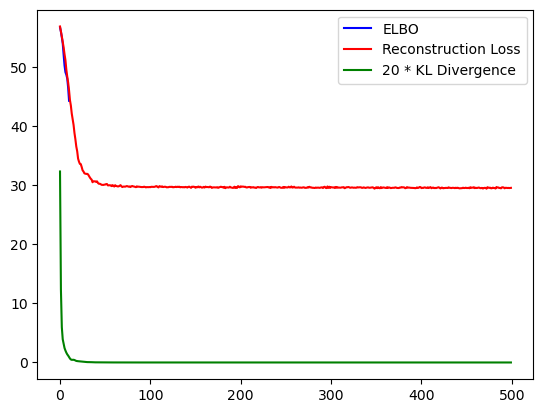

In [144]:
plt.figure()
plt.plot(losses, c='b', label="ELBO")
plt.plot(reconstruction_losses, c='r', label="Reconstruction Loss")
plt.plot(kl_divergences, c='g', label="20 * KL Divergence")
plt.legend()
plt.show()

Blue = original, Red = reconstructed


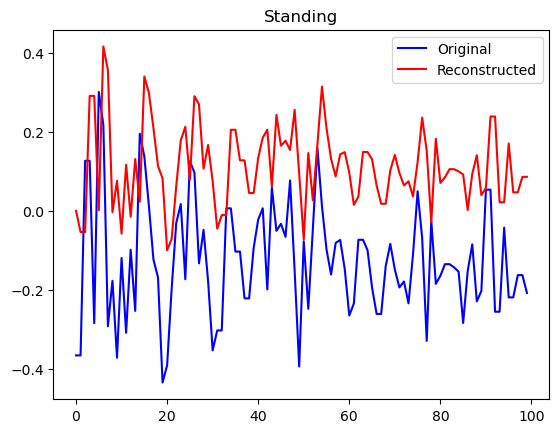

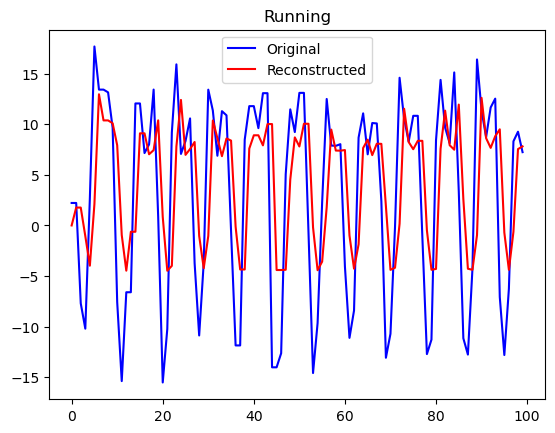

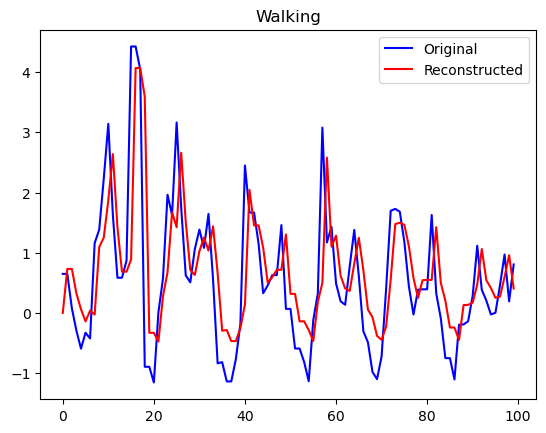

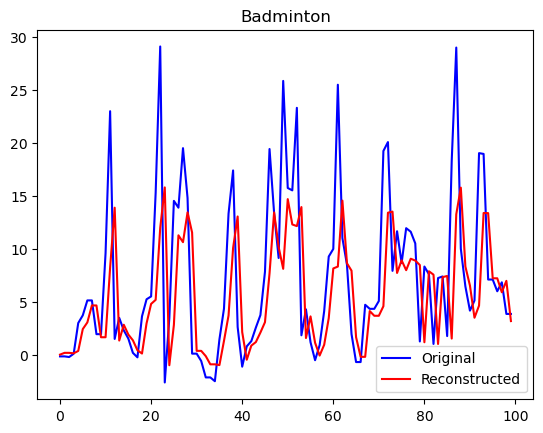

In [145]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), False)
for data_matrix, labels in data_load:
    inp = data_matrix[:, :, 0].unsqueeze(2).float()
    with torch.no_grad():
        output, _, _ = autoencoder(inp)
        print("Blue = original, Red = reconstructed")
        plt.figure()
        index = random.randint(0, 9)
        p1 = inp[index]
        p2 = output[index]

        plt.title("Standing")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.figure()
        index = random.randint(10, 19)
        p1 = inp[index]
        p2 = output[index]
 
        plt.title("Running")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.figure()
        index = random.randint(20, 29)
        p1 = inp[index]
        p2 = output[index]

        plt.title("Walking")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.figure()
        index = random.randint(30, 39)
        p1 = inp[index]
        p2 = output[index]

        plt.title("Badminton")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.show()




Blue = original, Red = reconstructed


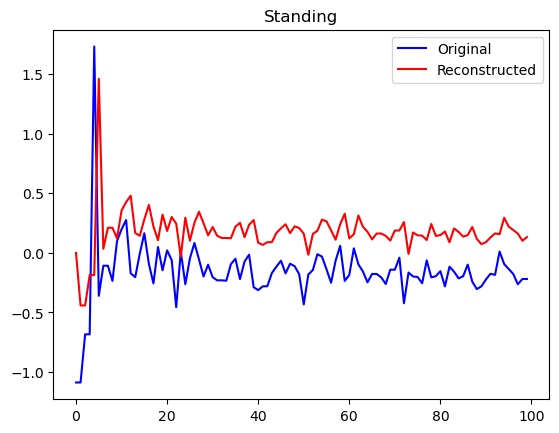

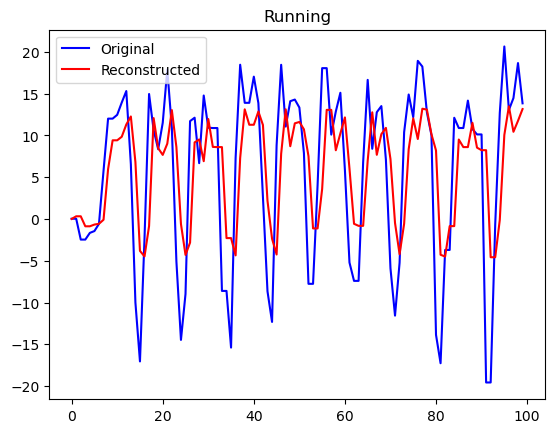

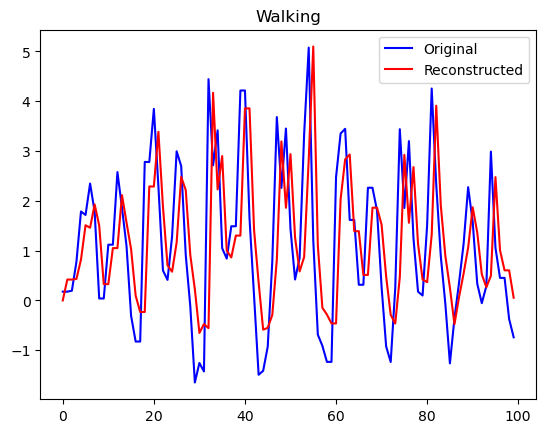

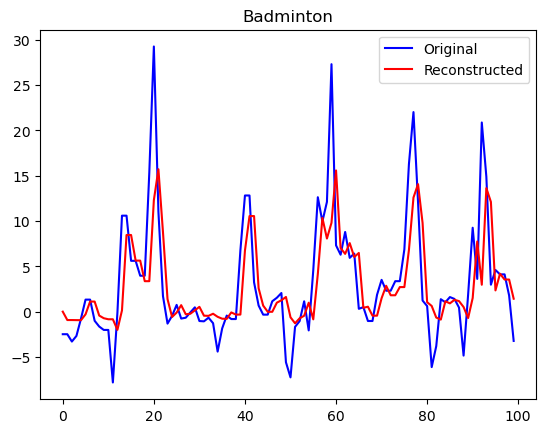

In [146]:
data_load = torch.utils.data.DataLoader(test_ds, len(test_ds), False)
for data_matrix, labels in data_load:
    inp = data_matrix[:, :, 0].unsqueeze(2).float()
    with torch.no_grad():
        output, _, _ = autoencoder(inp)
        print("Blue = original, Red = reconstructed")
        plt.figure()
        index = random.randint(0, 9)
        p1 = inp[index]
        p2 = output[index]

        plt.title("Standing")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.figure()
        index = random.randint(10, 19)
        p1 = inp[index]
        p2 = output[index]
 
        plt.title("Running")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.figure()
        index = random.randint(20, 29)
        p1 = inp[index]
        p2 = output[index]

        plt.title("Walking")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.figure()
        index = random.randint(30, 39)
        p1 = inp[index]
        p2 = output[index]

        plt.title("Badminton")
        plt.plot(p1, c='b', label="Original")
        plt.plot(p2, c='r', label="Reconstructed")
        plt.legend()

        plt.show()




In [147]:
from src.visualizations.umap_visualizer import UMAPLatent

standing: red, running: blue, walking: yellow, badminton: green
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


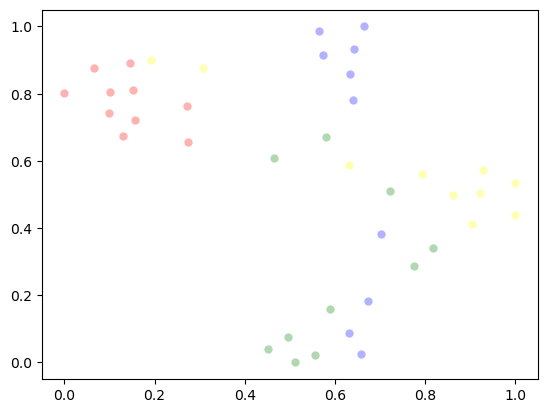

In [148]:
print("standing: red, running: blue, walking: yellow, badminton: green")
visualize_moment = torch.utils.data.DataLoader(train_ds, len(train_ds), True)
for sample in visualize_moment:
    inp, out = sample[0].detach(), sample[1].detach()
    inp = inp[:, :, 0].unsqueeze(2).float()
    with torch.no_grad():
        _, _, _, hidden, cell = autoencoder.encoder(inp)
        embeddings = hidden[-1, :, :]
        visualizer = UMAPLatent()
        visualizer.visualize(embeddings, out, 4)
plt.show()